In [ ]:
# Code for Screw Dislocation Modelling of the Herat fault
# Modified from https://github.com/andwatson/interseismic_practical
# For direct use on decomposed and merged dataset

In [1]:
# Import required modules. Run this before continuing.

# these are for performing the analysis
import numpy as np
from scipy import interpolate
from scipy import stats
import statistics
import pyproj
import subprocess as subp
from pathlib import Path

# this is our own library of functions, which can be found in the same directory as this notebook
import interseis_lib as lib

# this package is for general plotting
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# this is additional scientific colour maps, see "https://www.fabiocrameri.ch/colourmaps/"
from cmcrameri import cm

# these packages are only needed for the final multivariate plot
import seaborn as sns
import pandas as pd

# this refreshes the import of interseis_lib if changes are made while the notebook is running
import importlib
importlib.reload(lib)




### imports ###
import pygmt
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import matplotlib.image as mpimg 
from mpl_toolkits.basemap import Basemap

import pandas as pd

%matplotlib inline
%matplotlib widget

import os
import rasterio

In [2]:
### quick code to merge tif files ###
from rasterio.transform import from_origin

def merge_tiff_files(file_paths, output_file):
    # list all tiff files in the input folder
    tiff_files = [f for f in file_paths if f.endswith('.tif') or f.endswith('.tiff')]

    merged_array = np.zeros_like(img_array, dtype=np.float32)
    transform = src.transform
    crs = src.crs


    for file in tiff_files:
        with rasterio.open(file) as src:
            # Read the image data as an array
            img_array = src.read(1)
            merged_array += img_array


dir = "/Users/rochelle/Documents/GitHub/interseismic_practical/"
os.chdir(dir)

file_paths_str = ["bin/19-8-24_results/071A_05440_131313_078D_05435_131313_EW.mskd.geo.tif",\
                  "bin/19-8-24_results/144A_05476_141414_151D_05440_131313_EW.mskd.geo.adjusted.tif",\
                  "bin/19-8-24_results/144A_05476_141414_151D_05440_131313_EW.mskd.geo.adjusted.tif",\
                  "bin/19-8-24_results/042A_05535_131313_049D_05534_131313_EW.mskd.geo.adjusted.tif",\
                  "bin/19-8-24_results/115A_05608_131313_122D_05571_131313_EW.mskd.geo.adjusted.tif",\
                  "bin/19-8-24_results/115A_05409_131313_122D_05372_131313_EW.mskd.geo.adjusted.tif",\
                  "bin/19-8-24_results/042A_05336_131313_049D_05335_131313_EW.mskd.geo.adjusted.tif",\
                  "bin/19-8-24_results/144A_05476_141414_151D_05639_131313_EW.mskd.geo.adjusted.tif"]
output_file = 'bin/19-8-24_results/EW_merged_test.tif'

merge_tiff_files(file_paths_str, output_file)

UnboundLocalError: cannot access local variable 'img_array' where it is not associated with a value

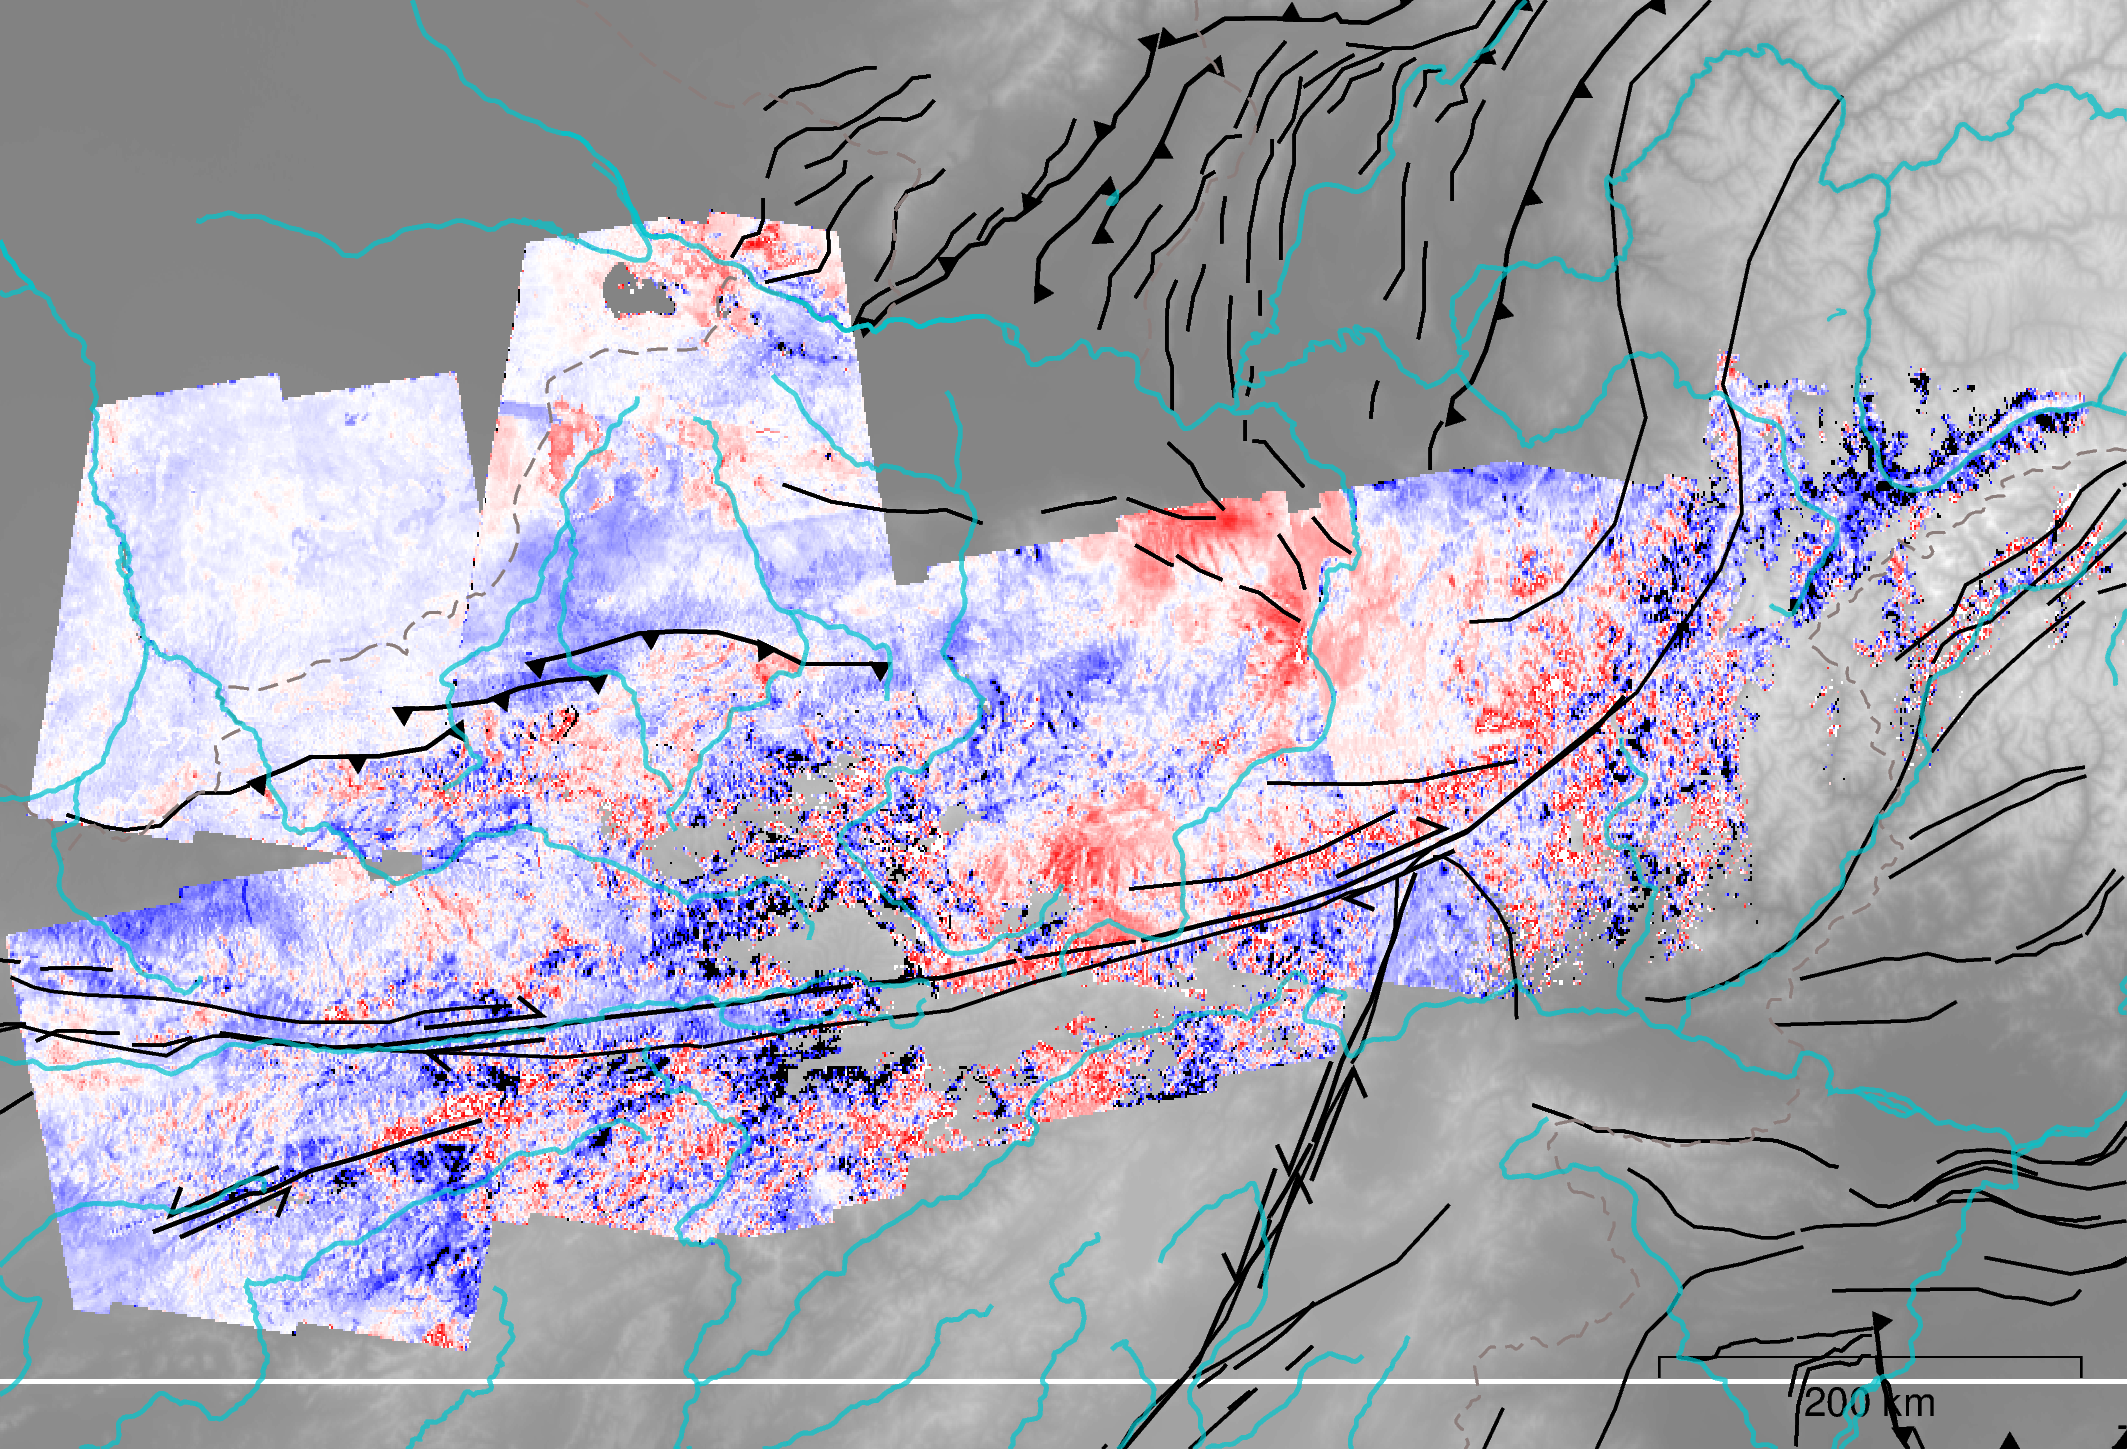

In [3]:
### dump base map code ###

###########################################
## Specify coords
# llcrnrlat,llcrnrlon, urcrnrlat, urcrnrlon
# are the lat/lon values of the lower left and upper right corners of the map

llcrnrlon=62 # lower left corner longitude 
llcrnrlat=32.65 # lower left corner latitude
urcrnrlon=72.8 # upper right corner longitude
urcrnrlat=38.65 # upper right corner latitude


proj_scale_w = 18 # specify projection scale (width)
proj_scale_unit = "c" # choose between c (cm) and i (inches)
# 17.78c = 7i

proj_subplot_scale = 2.3

meca_trans = 22 # meca transparency
meca_scale = "0.4c" # meca scale

input_tiff_path = "bin/8-8-24_results/EW_mskd_gdalmergefinal2.tif"

with rasterio.open(input_tiff_path) as tiff:
    vel = tiff.read(1) # returns band 1 as a numpy array

vel = vel.astype(float)
vel[vel == 0] = np.nan

###########################################
centerlon = (urcrnrlon - llcrnrlon)/2 + llcrnrlon # midpoints
centerlat = (urcrnrlat - llcrnrlat)/2 + llcrnrlat
region=[llcrnrlon, urcrnrlon, llcrnrlat, urcrnrlat]


fig = pygmt.Figure()
pygmt.config(MAP_FRAME_TYPE="fancy", FONT="Helvetica") # figure config (borders)


fig.coast(region=region,\
        projection="M%s/%s/%s%s" % (centerlon, centerlat, proj_scale_w, proj_scale_unit),\
        water="white", land="grey", shorelines="1/0.5p")

        # Mercator
        # a2f0.5 --> major ticks every 2 and minor ticks every 0.5

grid = pygmt.datasets.load_earth_relief("30s", registration="gridline", region=region)

fig.grdimage(grid=grid, cmap="bin/cpt/custom/seabluelandgrey.cpt")
# fig.grdimage(grid=grid, cmap="geo")

#######################
## plotting EW
pygmt.makecpt(output="bin/cpt/polar_LOSdecomp", series=[-10, 10], cmap="bin/cpt/GMT_supported/polar.cpt")
            # redefine scale + inverse
            # stored in local sesh

fig.grdimage(grid=input_tiff_path,\
                nan_transparent = True, transparency = 0, cmap="bin/cpt/polar_LOSdecomp")

'''                
fig.grdimage(grid="bin/8-8-24_results/071A_05440_131313_078D_05435_131313_EW.mskd.geo.tif"\
                , nan_transparent = True, transparency = 0, cmap="bin/cpt/polar_LOSdecomp")

fig.grdimage(grid="bin/8-8-24_results/144A_05476_141414_151D_05440_131313_EW.mskd.geo.adjusted.tif"\
                , nan_transparent = True, transparency = 0, cmap="bin/cpt/polar_LOSdecomp")

fig.grdimage(grid="bin/8-8-24_results/173A_05350_131313_005D_05398_131313_EW.mskd.geo.adjusted.tif"\
                , nan_transparent = True, transparency = 0, cmap="bin/cpt/polar_LOSdecomp")

fig.grdimage(grid="bin/8-8-24_results/042A_05535_131313_049D_05534_131313_EW.mskd.geo.adjusted.tif"\
                , nan_transparent = True, transparency = 0, cmap="bin/cpt/polar_LOSdecomp")

fig.grdimage(grid="bin/8-8-24_results/115A_05608_131313_122D_05571_131313_EW.mskd.geo.adjusted.tif"\
                , nan_transparent = True, transparency = 0, cmap="bin/cpt/polar_LOSdecomp")

fig.grdimage(grid="bin/8-8-24_results/115A_05409_131313_122D_05372_131313_EW.mskd.geo.adjusted.tif"\
                , nan_transparent = True, transparency = 0, cmap="bin/cpt/polar_LOSdecomp")

fig.grdimage(grid="bin/8-8-24_results/042A_05336_131313_049D_05335_131313_EW.mskd.geo.adjusted.tif"\
                , nan_transparent = True, transparency = 0, cmap="bin/cpt/polar_LOSdecomp")

fig.grdimage(grid="bin/8-8-24_results/144A_05476_141414_151D_05639_131313_EW.mskd.geo.adjusted.tif"\
                , nan_transparent = True, transparency = 0, cmap="bin/cpt/polar_LOSdecomp")
'''
#######################

## plotting faults
# https://www.pygmt.org/dev/gallery/lines/linefronts.html
fig.plot(data="bin/faults/HimaTibetMap.gmt", pen=f"0.7p,black") # all faults
fig.plot(data="bin/faults/gem_active_faults.gmt", pen=f"0.7p,black") # gem
fig.plot(data="bin/faults/normal.gmt", style="f1c/0.13c+l+b", pen=f"0.95p,black", fill="black") # normal
fig.plot(data="bin/faults/thrust.gmt", style="f1c/0.13c+l+t", pen=f"0.95p,black", fill="black") # thrust
fig.plot(data="bin/faults/dextral.gmt", style="f5c/1c+r+s45+o2.25c", pen=f"0.95p,black", fill="black") # dextral (right)
fig.plot(data="bin/faults/sinistral.gmt", style="f5c/1c+l+s45+o2.25c", pen=f"0.95p,black", fill="black") # sinistral (left)

fig.coast(map_scale="g71.5/33+w200k", shorelines="1/0.5p", borders="1/0.6p, mistyrose4,-")
fig.coast(lakes="turquoise3", rivers="a/1p,turquoise3,4_solid", water="turquoise3", transparency=30) # want water above national borders


fig.show()
fig.savefig("figures/frame_merge_map_EW_basemap.png")

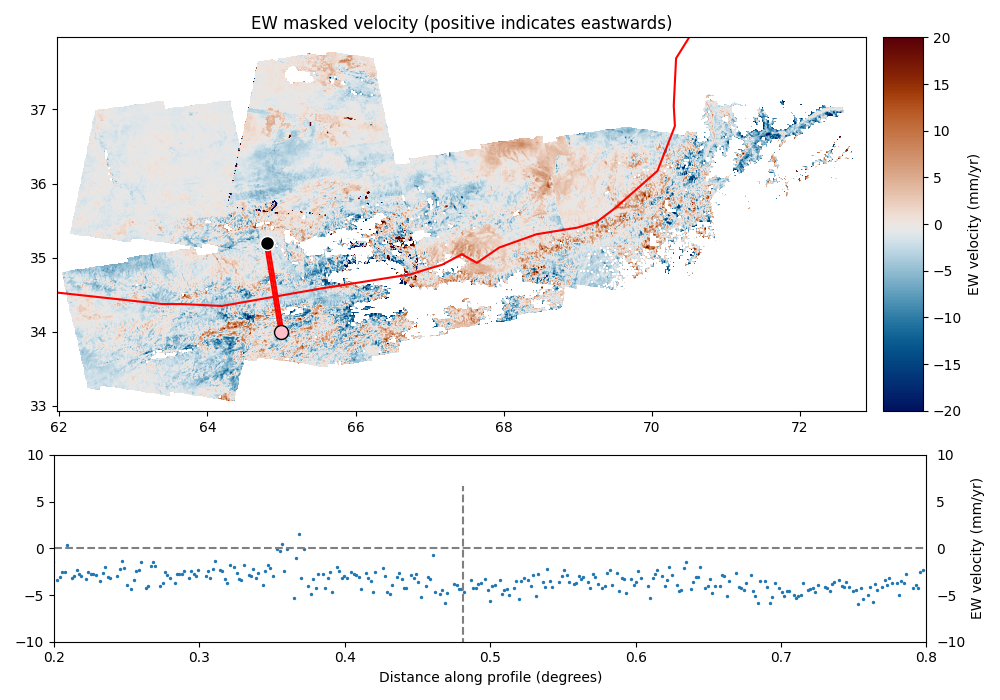

Metadata: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 1093, 'height': 505, 'count': 1, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.009999999999999993, 0.0, 61.970833,
       0.0, -0.009999999999999995, 37.977779)}
Bounding Box: BoundingBox(left=61.970833, bottom=32.927779, right=72.90083299999999, top=37.977779)
CRS: EPSG:4326
Affine Transformation: | 0.01, 0.00, 61.97|
| 0.00,-0.01, 37.98|
| 0.00, 0.00, 1.00|
Width: 1093
Height: 505
Pixel Size: (0.009999999999999993, 0.009999999999999995)


In [2]:
### simple profile plot ###


# opening geotiff
input_tiff_path = "bin/8-8-24_results/EW_mskd_gdalmergefinal2.tif"

with rasterio.open(input_tiff_path) as tiff:
    metadata = tiff.meta
    bounds = tiff.bounds # bounding box
    crs = tiff.crs # coordinate reference sysrtem crs
    transform = tiff.transform # afine transformation (geotransform)
    width = tiff.width # raster width and height
    length = tiff.height
    pixel_size = tiff.res # pixel size

    vel_E = tiff.read(1) # returns band 1 as a numpy array

vel_E = vel_E.astype(float)
vel_E[vel_E == 0] = np.nan


# i am manually importing this data from gdalinfo

# corner positions
# this is llcrnrlon lat Bounding Box: BoundingBox(left=61.970833, bottom=32.927779, right=72.90083299999999, top=37.977779)
corner_lon = float(61.970833)
corner_lat = float(32.927779)


# get post spacing (distance between velocity measurements)
post_lon = float(0.01) # in degrees
post_lat = float(0.01)


# calculate grid spacing
lon_spac = corner_lon + post_lon*np.arange(1,width+1) - post_lon/2
lat_spac = corner_lat + post_lat*np.arange(1,length+1) - post_lat/2

# load the Herat fault trace
fault_trace = np.loadtxt(Path('bin/faults/Herat_trace.xy'))


# start and end coordinates of the profile, and extra parameters
#####################################
prof_start = (65, 34)
prof_end = (64.8, 35.2)
prof_params = {
    "nbins": 100, # number of bins to split the profile into
    "width": 0.05 # total width of the profile in degrees (1 degree ~ 110 km)
}
#####################################

# run the profiler, the outputs are as follows:
# - bin_val = mean value of each bin
# - prof_bin_mids = distance along the profile to the middle of each bin
# - points_val = every velocity within the profile
# - points_dist = distance along the profile to every point within the profile
# - points_poly = polygon that defines the profile
bin_val, prof_bin_mids, points_val, points_dist, points_poly \
    = lib.profile_data(lon_spac,lat_spac,vel_E,prof_start,prof_end,prof_params)

# calculate profile-fault intersection angle
intersect_dist, intersect_angle = lib.profile_fault_intersection(prof_start,prof_end,fault_trace)

# plot vel and the profiled data
fig, axs = plt.subplots(2,1,figsize=(10,7), gridspec_kw={'height_ratios': [2, 1]})


# velocity map
im = axs[0].imshow(vel_E, extent=[np.amin(lon_spac), np.amax(lon_spac), np.amin(lat_spac), np.amax(lat_spac)], \
                   cmap=cm.vik, vmin=-20, vmax=20)
axs[0].plot(fault_trace[:,0], fault_trace[:,1], color="red")
axs[0].plot([prof_start[0], prof_end[0]], [prof_start[1], prof_end[1]], color="red")
axs[0].plot(points_poly[:,0],points_poly[:,1], color="red")
axs[0].scatter(prof_start[0],prof_start[1], s=100, color='pink', edgecolor='black', zorder=3)
axs[0].scatter(prof_end[0],prof_end[1], s=100, color='black', edgecolor='white', zorder=3)
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad="2%")
plt.colorbar(im, cax=cax, label='EW velocity (mm/yr)')
axs[0].set_title('EW masked velocity (positive indicates eastwards)')
axs[0].set_xlim(np.amin(lon_spac), np.amax(lon_spac))
axs[0].set_ylim(np.amin(lat_spac), np.amax(lat_spac))

# velocities projected onto profile
axs[1].scatter(points_dist, points_val, s=2)
axs[1].plot([intersect_dist, intersect_dist],[axs[1].get_ylim()[0], axs[1].get_ylim()[1]], color='grey', linestyle='dashed')
axs[1].plot([axs[1].get_xlim()[0], axs[1].get_xlim()[1]], [0, 0], color='grey', linestyle='dashed')
axs[1].set_xlim([0.2, 0.8])
axs[1].set_ylim([-10, 10])
axs[1].tick_params(labelright=True)
axs[1].yaxis.set_label_position("right")
axs[1].set_xlabel("Distance along profile (degrees)")
axs[1].set_ylabel("EW velocity (mm/yr)")

fig.tight_layout()
plt.show()



# Print the extracted parameters
print("Metadata:", metadata)
print("Bounding Box:", bounds)
print("CRS:", crs)
print("Affine Transformation:", transform)
print("Width:", width)
print("Height:", length)
print("Pixel Size:", pixel_size)



In [3]:
# reprofiling from lonlat to UTM (metres)
# pre-allocate
# limits and intervals for new grid
lon_min = float(61.9708330)
lon_max = float(72.90083299999999)
lon_int = post_lon
lon_regrid = np.arange(lon_min,lon_max,lon_int)

lat_max = float(37.9777790)
lat_min = float(32.9277790)
lat_int = post_lat
lat_regrid = np.arange(lat_min,lat_max,lat_int)


# stuff to get the code below to work
xx, yy = np.meshgrid(lon_spac, lat_spac)
vel_regrid = interpolate.griddata((xx.ravel(), yy.ravel()), vel_E.ravel(), (xx.ravel(), yy.ravel()))
vel_regrid = vel_regrid.reshape((len(lat_regrid),len(lon_regrid)))

input_tiff_path = "bin/8-8-24_results/UD_mskd_gdalmerge2.tif"

with rasterio.open(input_tiff_path) as tiff:
    vel_U = tiff.read(1) # returns band 1 as a numpy array

vel_U = vel_U.astype(float)
vel_U[vel_U == 0] = np.nan

# 'unit vectors'
E = vel_E.reshape((length, width))
U = vel_U.reshape((length, width))
E_regrid = interpolate.griddata((xx.ravel(), yy.ravel()), E.ravel(), (xx.ravel(), yy.ravel())).reshape((len(lat_regrid),len(lon_regrid)))
U_regrid = interpolate.griddata((xx.ravel(), yy.ravel()), U.ravel(), (xx.ravel(), yy.ravel())).reshape((len(lat_regrid),len(lon_regrid)))


# get the utm zone projection
# BoundingBox(left=61.970833, bottom=32.927779, right=72.90083299999999, top=37.977779)
utm_crs_list = pyproj.database.query_utm_crs_info(
    datum_name="WGS 84",
    area_of_interest = pyproj.aoi.AreaOfInterest(
        west_lon_degree  = np.amin(lon_regrid),
        south_lat_degree = np.amin(lat_regrid),
        east_lon_degree  = np.amax(lon_regrid),
        north_lat_degree = np.amax(lat_regrid),
    ),
)
utm_crs = pyproj.CRS.from_epsg(utm_crs_list[0].code)


# create transformer for LL to UTM
transformer = pyproj.Transformer.from_crs('epsg:4326', utm_crs)

# apply transform to our grids of lat long coordinates
xx_utm, yy_utm = transformer.transform(yy, xx)


# apply transform to fault trace
fault_trace_utm = fault_trace.copy()
fault_trace_utm[:,0], fault_trace_utm[:,1] = transformer.transform(fault_trace[:,1], fault_trace[:,0])

# convert utm metres to km (easier to work with for plotting)
xx_utm = xx_utm / 1000
yy_utm = yy_utm / 1000
fault_trace_utm = fault_trace_utm / 1000

print("done")

done


In [4]:
# get new limits for plotting
val_ind_row, val_ind_col = np.where(~np.isnan(vel_U).all(axis=0))[0], np.where(~np.isnan(vel_U).all(axis=1))[0]
xlim = [xx_utm[-1,val_ind_row[0]], xx_utm[-1,val_ind_row[-1]]]
ylim = [yy_utm[val_ind_col[0],0], yy_utm[val_ind_col[-1],0]]  # changed this around as it was being plotted the other way for some reason

# to make this plot normally for some god forsaken reason the y velocities are mirrored
reflection_plane = (((yy_utm[val_ind_col[-1],0]) - (yy_utm[val_ind_col[0],0])) / 2) + (yy_utm[val_ind_col[0],0])
# reflect y-coordinates
yy_utm_reflected = 2 * reflection_plane - yy_utm
# interpolate the velocities onto the reflected grid
E_reflected = interpolate.griddata((xx_utm.ravel(), yy_utm_reflected.ravel()), vel_E.ravel(), (xx_utm, yy_utm))
U_reflected = interpolate.griddata((xx_utm.ravel(), yy_utm_reflected.ravel()), vel_U.ravel(), (xx_utm, yy_utm))

# print(ylim)

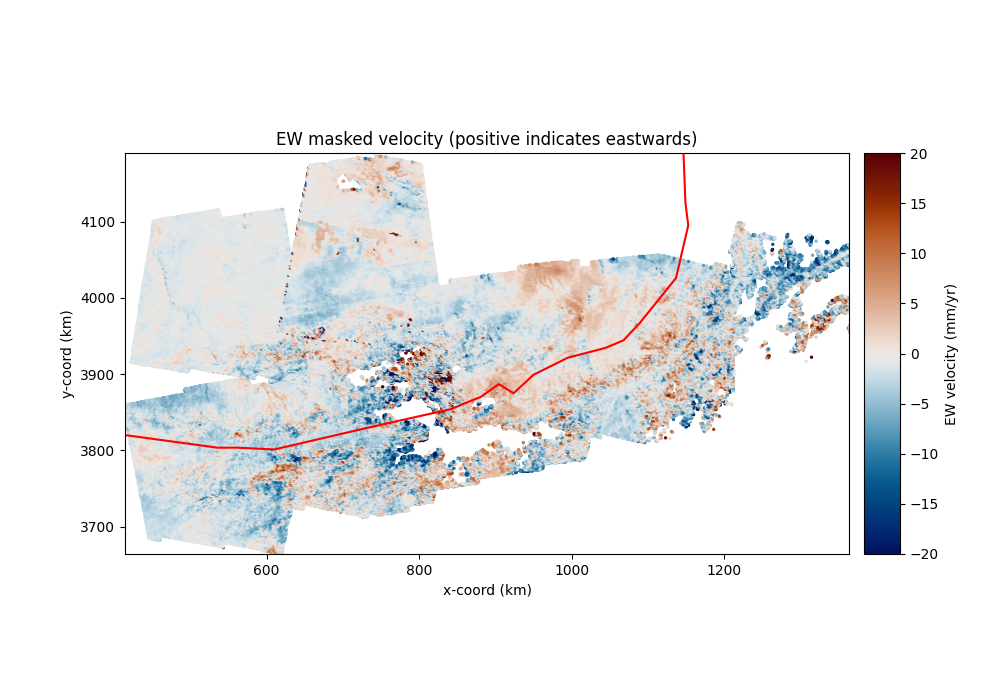

In [126]:
'''
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import matplotlib.image as mpimg 
from mpl_toolkits.basemap import Basemap
'''

# replot with new coordinates
fig = plt.figure(figsize=(10,7))
axs = plt.subplot(111)

# East velocities
im = axs.scatter(xx_utm.flatten(), yy_utm.flatten(), s=2, c=E_reflected.flatten(), cmap=cm.vik, vmin=-20, vmax=20)
axs.plot(fault_trace_utm[:,0], fault_trace_utm[:,1], color="red")
divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad="2%")
plt.colorbar(im, cax=cax, label='EW velocity (mm/yr)')
axs.set_aspect('equal', 'box')
axs.set_title('EW masked velocity (positive indicates eastwards)')
axs.set_xlabel('x-coord (km)')
axs.set_ylabel('y-coord (km)')
axs.set_xlim(xlim)
axs.set_ylim(ylim)


# because this thing is for some godforsaken reason reflected and ylim isnt giving me the right reflection plane
# 3652 4183
pos=[]
def onclick(event):
    pos.append([event.xdata, event.ydata])

    axs.set_title(f'Click {len(pos)}: {event.xdata}, {event.ydata}') 

    
cid=fig.canvas.mpl_connect('button_press_event', onclick)

%matplotlib widget

plt.show()

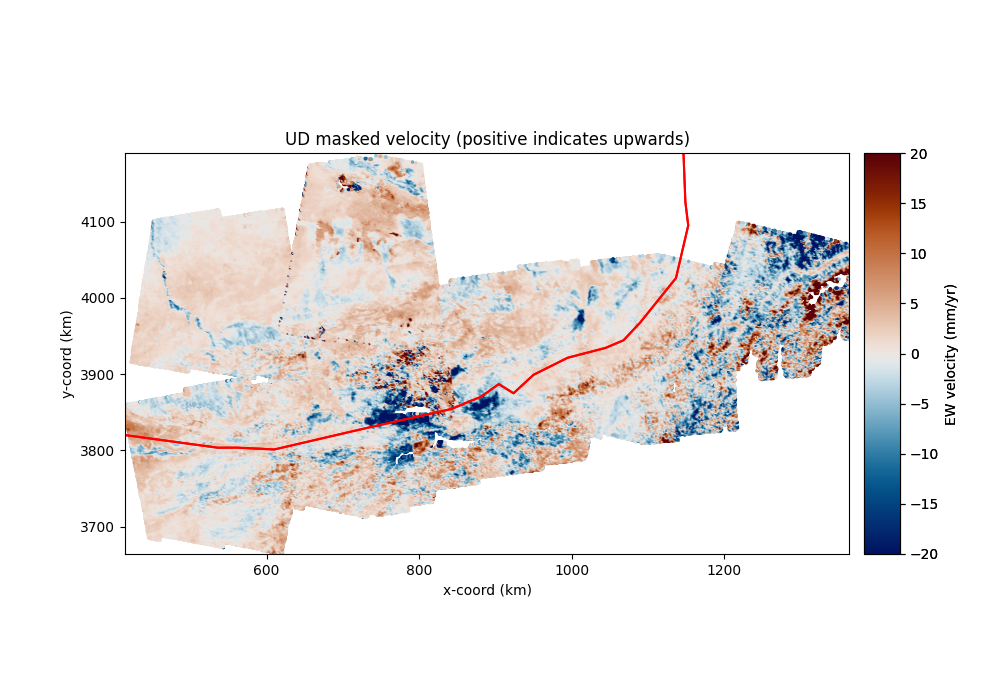

In [11]:
# Up velocities
im = axs.scatter(xx_utm.flatten(), yy_utm.flatten(), s=2, c=U_reflected.flatten(), cmap=cm.vik, vmin=-20, vmax=20)
axs.plot(fault_trace_utm[:,0], fault_trace_utm[:,1], color="red")
divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad="2%")
plt.colorbar(im, cax=cax, label='EW velocity (mm/yr)')
axs.set_aspect('equal', 'box')
axs.set_title('UD masked velocity (positive indicates upwards)')
axs.set_xlabel('x-coord (km)')
axs.set_ylabel('y-coord (km)')
axs.set_xlim(xlim)
axs.set_ylim(ylim)
plt.show()

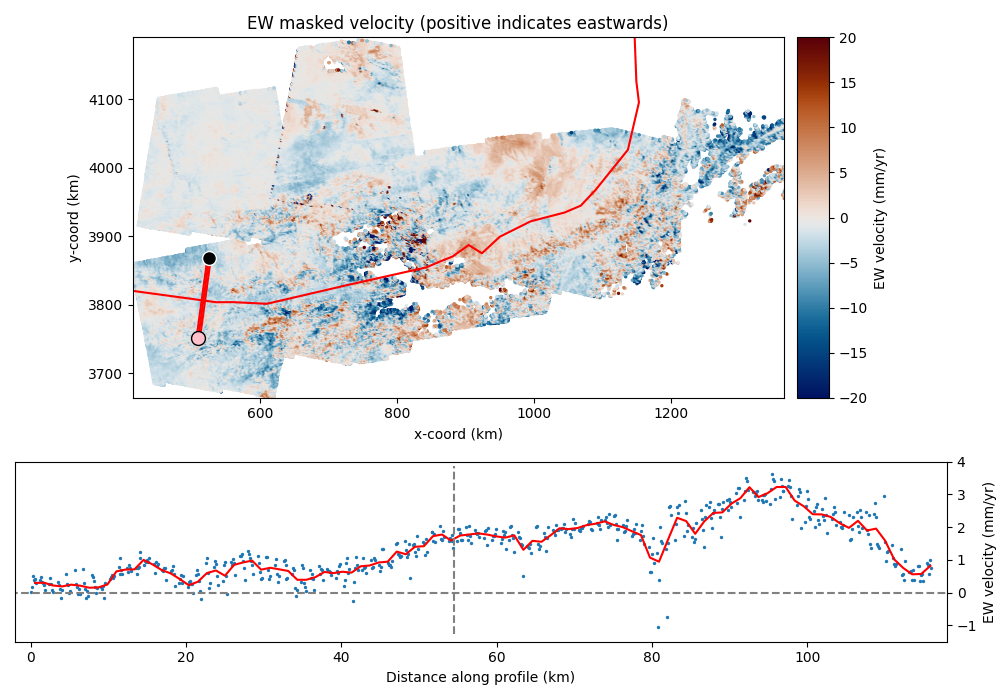

In [163]:
# Set the profile parameters


#####################################
# prof_start = (710, 3767)
# prof_end = (675, 3885)
prof_start = (pos[-2][0], pos[-2][1])
prof_end = (pos[-1][0], pos[-1][1])
prof_params = {
    "nbins": 100, # number of bins to split the profile into
    "width": 5  # total width of the profile in km
}
#####################################

# run the profiler
bin_val, prof_bin_mids, points_val, points_dist, points_poly \
    = lib.profile_data(xx_utm,yy_utm,vel_U,prof_start,prof_end,prof_params)

# calculate profile-fault intersection angle
intersect_dist, intersect_angle = lib.profile_fault_intersection(prof_start,prof_end,fault_trace_utm)

# plot
fig, axs = plt.subplots(2,1,figsize=(10,7), gridspec_kw={'height_ratios': [2, 1]})

# East velocities
im = axs[0].scatter(xx_utm.flatten(), yy_utm.flatten(), s=2, c=E_reflected.flatten(), cmap=cm.vik, vmin=-20, vmax=20)
axs[0].plot(fault_trace_utm[:,0], fault_trace_utm[:,1], color="red")
axs[0].plot([prof_start[0], prof_end[0]], [prof_start[1], prof_end[1]], color="red")
axs[0].plot(points_poly[:,0],points_poly[:,1], color="red")
axs[0].scatter(prof_start[0],prof_start[1], s=100, color='pink', edgecolor='black', zorder=3)
axs[0].scatter(prof_end[0],prof_end[1], s=100, color='black', edgecolor='white', zorder=3)
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad="2%")
plt.colorbar(im, cax=cax, label='EW velocity (mm/yr)')
axs[0].set_aspect('equal', 'box')
'''
# twin axes for top and right
ax_top = axs[0].twinx() 
ax_right = axs[0].twiny()
ax_top.set_xlim(np.amin(lon_spac), np.amax(lon_spac))
ax_right.set_ylim(np.amin(lat_spac), np.amax(lat_spac))

ax_right.spines['right']
ax_right.spines['left'].set_visible(False)
ax_top.spines['top']
ax_top.spines['bottom'].set_visible(False)
'''

axs[0].set_title('EW masked velocity (positive indicates eastwards)')
axs[0].set_xlabel('x-coord (km)')
axs[0].set_ylabel('y-coord (km)')
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)

# profile
axs[1].scatter(points_dist,points_val, s=2)
axs[1].plot(prof_bin_mids,bin_val,color="red")
axs[1].plot([intersect_dist, intersect_dist],[axs[1].get_ylim()[0], axs[1].get_ylim()[1]], color='grey', linestyle='dashed')
axs[1].plot([axs[1].get_xlim()[0], axs[1].get_xlim()[1]], [0, 0], color='grey', linestyle='dashed')
axs[1].set_ylim([-1.5, 4])
axs[1].set_xlim([-2, 118])
axs[1].tick_params(labelright=True)
axs[1].set_xlabel("Distance along profile (km)")
axs[1].set_ylabel("EW velocity (mm/yr)")
axs[1].yaxis.set_label_position("right")
axs[1].yaxis.tick_right()

fig.tight_layout(w_pad=4)
plt.show()


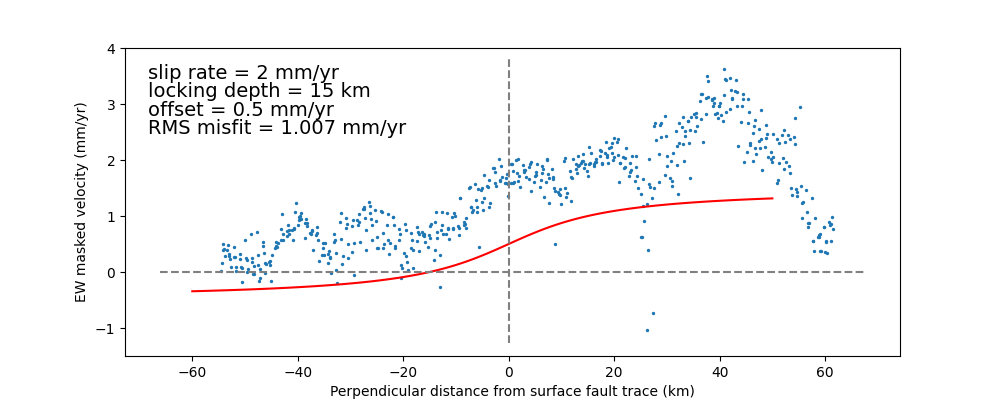

In [142]:
# Slip, locking depth, and offset
#####################################
s = 2 # mm/yr
d = 15 # km
c = 0.5 # mm/yr constant???
#####################################

# shift profile so that the fault is at 0 km
x_prof = points_dist - intersect_dist

# Vector of positions every 1 km for -100 km to 100 km
x = np.arange(-60,51,1)

# run the forward model
v = lib.screw_disc(x*1000, s/1000, d*1000, c/1000)

# calculate rms misfit by running the forward model for x positions with velocities
v_forward = lib.screw_disc(x_prof*1000, s/1000, d*1000, c/1000)
rms_forward = lib.rms_misfit(points_val,v_forward*1000)

# Plot comparison
fig, axs = plt.subplots(1,1,figsize=(10,4))

plt.scatter(x_prof,points_val, s=2)
plt.plot(x, v*1000, c='r')
plt.plot([0, 0],[axs.get_ylim()[0], axs.get_ylim()[1]], color='grey', linestyle='dashed')
plt.plot([axs.get_xlim()[0], axs.get_xlim()[1]], [0, 0], color='grey', linestyle='dashed')
axs.set_ylim([-5, 5])
plt.text(0.03, 0.9, 'slip rate = ' + str(s) + ' mm/yr', fontsize=14, transform = axs.transAxes)
plt.text(0.03, 0.84, 'locking depth = ' + str(d) + ' km', fontsize=14, transform = axs.transAxes)
plt.text(0.03, 0.78, 'offset = ' + str(c) + ' mm/yr', fontsize=14, transform = axs.transAxes)
plt.text(0.03, 0.72, 'RMS misfit = ' + str(round(rms_forward,3)) + ' mm/yr', fontsize=14, transform = axs.transAxes)

plt.xlabel('Perpendicular distance from surface fault trace (km)')
plt.ylabel('EW masked velocity (mm/yr)')

plt.show()

In [128]:
importlib.reload(lib)
np.random.seed(1)

# inversion setup
#####################################
n_iterations = 10000 # don't go above this value of 10,000 in the practical
#####################################

# take profiled velocities and shift the fault to be at zero + 5km
x_prof = points_dist - intersect_dist + 5
v_prof = points_val

# model params and their limits
m_start = np.array([5, 5, 0], dtype=np.double) # slip in mm/yr, locking depth in km
m_min = np.array([-20, 1, -10], dtype=np.double) # 0 1 -10
m_max = np.array([30, 30, 10], dtype=np.double) # 40 50 10

# variance-covariance matrix, currently 1 mm/yr uncertainties
vcm = np.eye(len(x_prof))

# convert all units to metres
x = x_prof * 1000
v = v_prof / 1000
m_start = m_start * np.array([0.001, 1000, 0.001])
m_min = m_min * np.array([0.001, 1000, 0.001])
m_max = m_max * np.array([0.001, 1000, 0.001])
vcm = vcm / 1e6

# inversion setup
burn_in = round(n_iterations/100)
acceptance_coef = 0.001

# weightings
W = np.linalg.inv(vcm)

# pre-allocate arrays
models_saved=np.zeros((n_iterations,len(m_start))) * np.nan
ll_saved=np.zeros((n_iterations,1)) * np.nan
n_accept = 0 # number of accepted models
n_reject = 0 # number of rejected models

# pass starting model to current model
m_current = m_start.copy()

# run inversion
for ii in range(n_iterations):
    
    # propose model using different step sizes for each parameter
    m_trial = m_current.copy()
    m_trial[0] = m_trial[0] + np.random.normal(loc=0, scale=2.5, size=1)/1000 # slip rate
    m_trial[1] = m_trial[1] + np.random.normal(loc=0, scale=2.5, size=1)*1000 # locking depth
    m_trial[2] = m_trial[2] + np.random.normal(loc=0, scale=1, size=1)/1000 # offset
    
    # check limits and skip the rest of the loop if any parameter is invalid
    if not(lib.prior(m_trial,m_min,m_max)):
        n_reject += 1
        models_saved[ii,:] = m_current
        continue
    
    # calculate likelihood for the current and trial models
    ll_current = lib.likelihood(x, v, m_current, W)
    ll_trial = lib.likelihood(x, v, m_trial, W)
    
    # test whether to keep trial model
    #if np.exp(acceptance_coef*(ll_trial-ll_current)) > np.random.uniform(low=0, high=1,size=1):
    if np.exp(acceptance_coef*(ll_current-ll_trial)) > np.random.uniform(low=0, high=1,size=1):
        m_current = m_trial
        ll_current = ll_trial
        n_accept += 1
    else:
        n_reject += 1
    models_saved[ii,:] = m_current
    ll_saved[ii] = ll_current
    
# convert back from metres to mm/yr and km
models_saved[:,0] = models_saved[:,0] * 1000 # slip rate
models_saved[:,1] = models_saved[:,1] / 1000 # locking depth
models_saved[:,2] = models_saved[:,2] * 1000 # offset

# find best fit model using min of likelihood function
best_model = models_saved[np.nanargmin(ll_saved),:]

print('Inversion complete')
print('Number of accepted models = ' + str(n_accept))
print('Number of rejected models = ' + str(n_reject))

/var/folders/xp/d0lbwvf108l78qt1c6tlwylh0000gn/T/ipykernel_74744/1901032255.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m_trial[0] = m_trial[0] + np.random.normal(loc=0, scale=2.5, size=1)/1000 # slip rate
/var/folders/xp/d0lbwvf108l78qt1c6tlwylh0000gn/T/ipykernel_74744/1901032255.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m_trial[1] = m_trial[1] + np.random.normal(loc=0, scale=2.5, size=1)*1000 # locking depth
/var/folders/xp/d0lbwvf108l78qt1c6tlwylh0000gn/T/ipykernel_74744/1901032255.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract 

Inversion complete
Number of accepted models = 5258
Number of rejected models = 4742


Text(0, 0.5, 'Locking depth (km)')

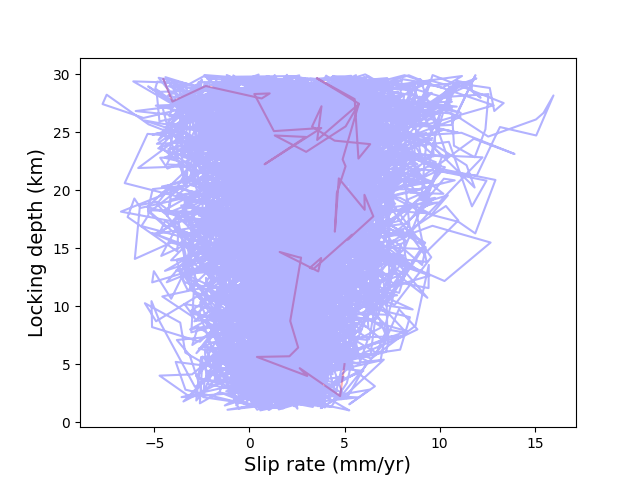

In [161]:
# plot walker 
plt.figure()
plt.plot(models_saved[:burn_in,0], models_saved[:burn_in,1], color='red', alpha=0.3)
plt.plot(models_saved[burn_in:,0], models_saved[burn_in:,1], color='blue', alpha=0.3)
plt.xlabel('Slip rate (mm/yr)', fontsize=14)
plt.ylabel('Locking depth (km)', fontsize=14)

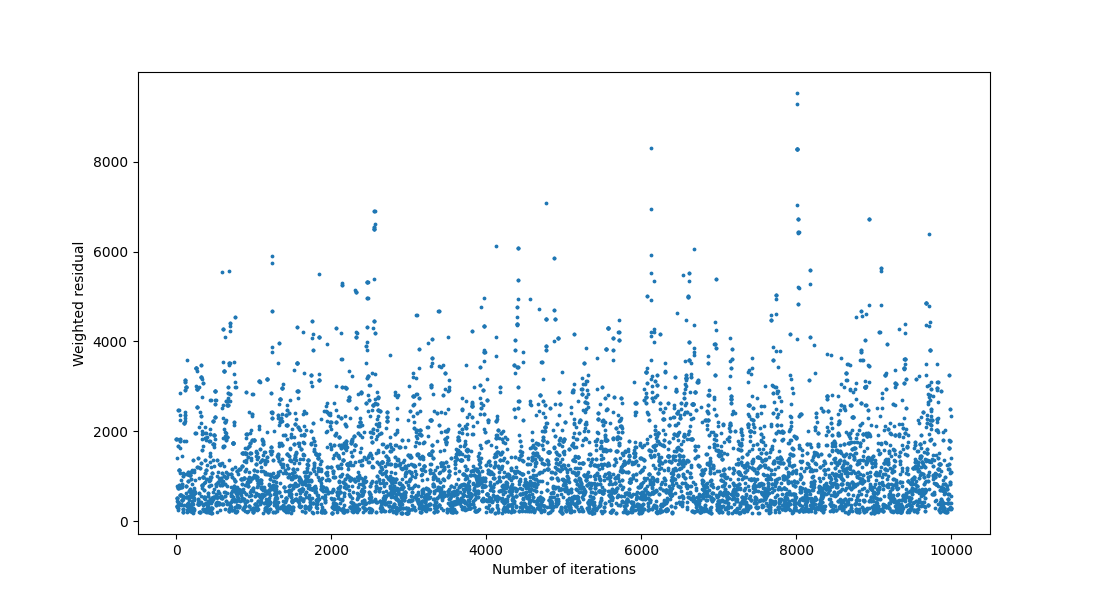

In [130]:
# plot likelihood value throughout monte carlo
fig, axs = plt.subplots(1,1,figsize=(11,6))

axs.scatter(np.arange(1,len(ll_saved)+1),ll_saved, s=3)
axs.set_xlabel('Number of iterations')
axs.set_ylabel('Weighted residual')

plt.show()

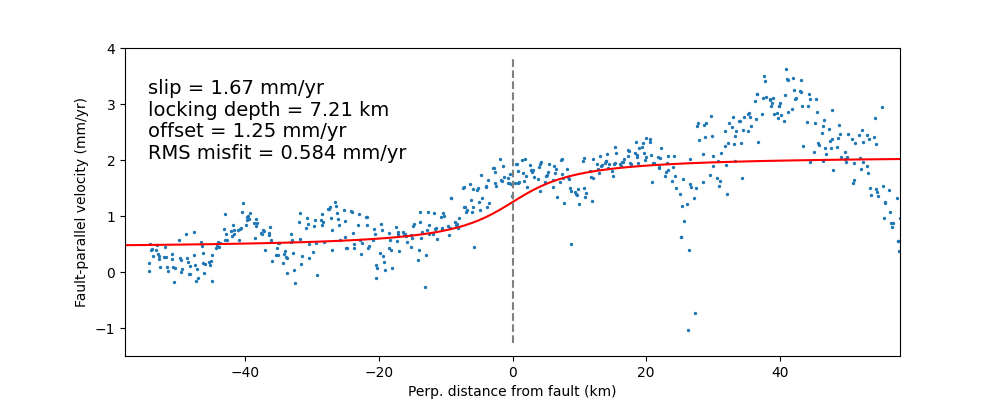

In [156]:
# calculate rms misfit
v_final = lib.screw_disc(x_prof, best_model[0], best_model[1], best_model[2])
best_rms = lib.rms_misfit(v_prof,v_final)

# for plotting
x = np.arange(-60,61,1)
v_final_plot = lib.screw_disc(x, best_model[0], best_model[1], best_model[2])

# Plot comparison
fig, axs = plt.subplots(1,1,figsize=(10,4))
yshift_text = 0.05
plt.scatter(x_prof,v_prof,s=2)
plt.plot(x, v_final_plot, c='r')
plt.plot([0, 0],[axs.get_ylim()[0], axs.get_ylim()[1]], color='grey', linestyle='dashed')
axs.set_xlim([-58, 58])
axs.xaxis.grid(True, which='minor')
axs.set_ylim([-1.5, 4])
plt.text(0.03, 0.8 + yshift_text, 'slip = ' + str(round(best_model[0],2)) + ' mm/yr', fontsize=14, transform = axs.transAxes)
plt.text(0.03, 0.74 + yshift_text - 0.01, 'locking depth = ' + str(round(best_model[1],2)) + ' km', fontsize=14, transform = axs.transAxes)
plt.text(0.03, 0.68 + yshift_text - 0.02, 'offset = ' + str(round(best_model[2],2)) + ' mm/yr', fontsize=14, transform = axs.transAxes)
plt.text(0.03, 0.62 + yshift_text - 0.03, 'RMS misfit = ' + str(round(best_rms,3)) + ' mm/yr', fontsize=14, transform = axs.transAxes)

plt.xlabel('Perp. distance from fault (km)')
plt.ylabel('Fault-parallel velocity (mm/yr)')

plt.show()

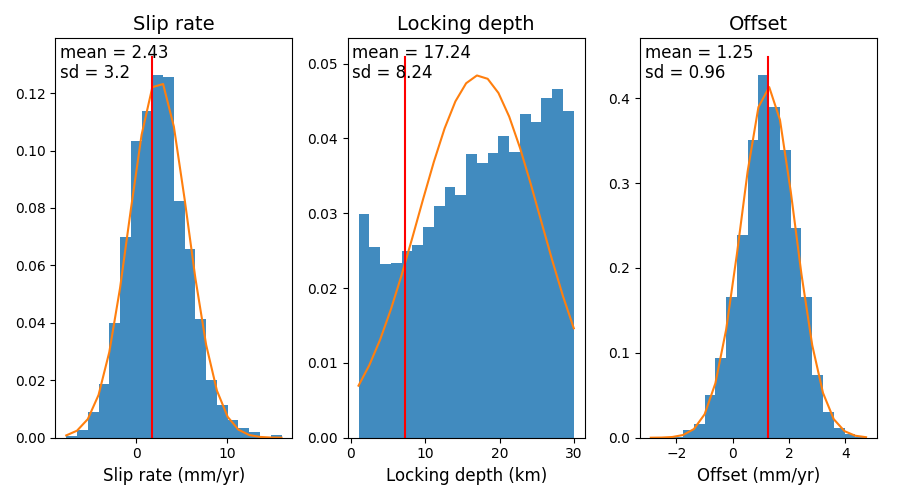

In [164]:
# calculate mean and standard deviation for each parameter
gauss_s = stats.norm.fit(models_saved[burn_in:,0])
gauss_d = stats.norm.fit(models_saved[burn_in:,1])
gauss_c = stats.norm.fit(models_saved[burn_in:,2])

# create figure
fig, axs = plt.subplots(1, 3, figsize=(9,5))

# plot histograms
_, bins_s, _ = axs[0].hist(models_saved[burn_in:,0], bins=20, density=True, alpha=0.85)
_, bins_d, _ = axs[1].hist(models_saved[burn_in:,1], bins=20, density=True, alpha=0.85)
_, bins_c, _ = axs[2].hist(models_saved[burn_in:,2], bins=20, density=True, alpha=0.85)

# create gaussian fit lines
gauss_fit_s = stats.norm.pdf(bins_s, gauss_s[0], gauss_s[1])
gauss_fit_d = stats.norm.pdf(bins_d, gauss_d[0], gauss_d[1])
gauss_fit_c = stats.norm.pdf(bins_c, gauss_c[0], gauss_c[1])

# plot gaussian fits
axs[0].plot(bins_s, gauss_fit_s)
axs[1].plot(bins_d, gauss_fit_d)
axs[2].plot(bins_c, gauss_fit_c)

# label mean and sd
yshift_text = -0.02
axs[0].text(0.02, 0.97 + yshift_text, 'mean = ' + str(round(gauss_s[0],2)), fontsize=12, transform = axs[0].transAxes)
axs[0].text(0.02, 0.94 + yshift_text - 0.02, 'sd = ' + str(round(gauss_s[1],2)), fontsize=12, transform = axs[0].transAxes)
axs[1].text(0.02, 0.97 + yshift_text, 'mean = ' + str(round(gauss_d[0],2)), fontsize=12, transform = axs[1].transAxes)
axs[1].text(0.02, 0.94 + yshift_text - 0.02, 'sd = ' + str(round(gauss_d[1],2)), fontsize=12, transform = axs[1].transAxes)
axs[2].text(0.02, 0.97 + yshift_text, 'mean = ' + str(round(gauss_c[0],2)), fontsize=12, transform = axs[2].transAxes)
axs[2].text(0.02, 0.94 + yshift_text - 0.02, 'sd = ' + str(round(gauss_c[1],2)), fontsize=12, transform = axs[2].transAxes)

# plot best model values
axs[0].plot([best_model[0], best_model[0]],[0, axs[0].get_ylim()[1]], color="red")
axs[1].plot([best_model[1], best_model[1]],[0, axs[1].get_ylim()[1]], color="red")
axs[2].plot([best_model[2], best_model[2]],[0, axs[2].get_ylim()[1]], color="red")

axs[0].set_title('Slip rate', fontsize=14)
axs[1].set_title('Locking depth', fontsize=14)
axs[2].set_title('Offset', fontsize=14)

axs[0].set_xlabel('Slip rate (mm/yr)', fontsize=12)
axs[1].set_xlabel('Locking depth (km)', fontsize=12)
axs[2].set_xlabel('Offset (mm/yr)', fontsize=12)

fig.tight_layout()
plt.show()

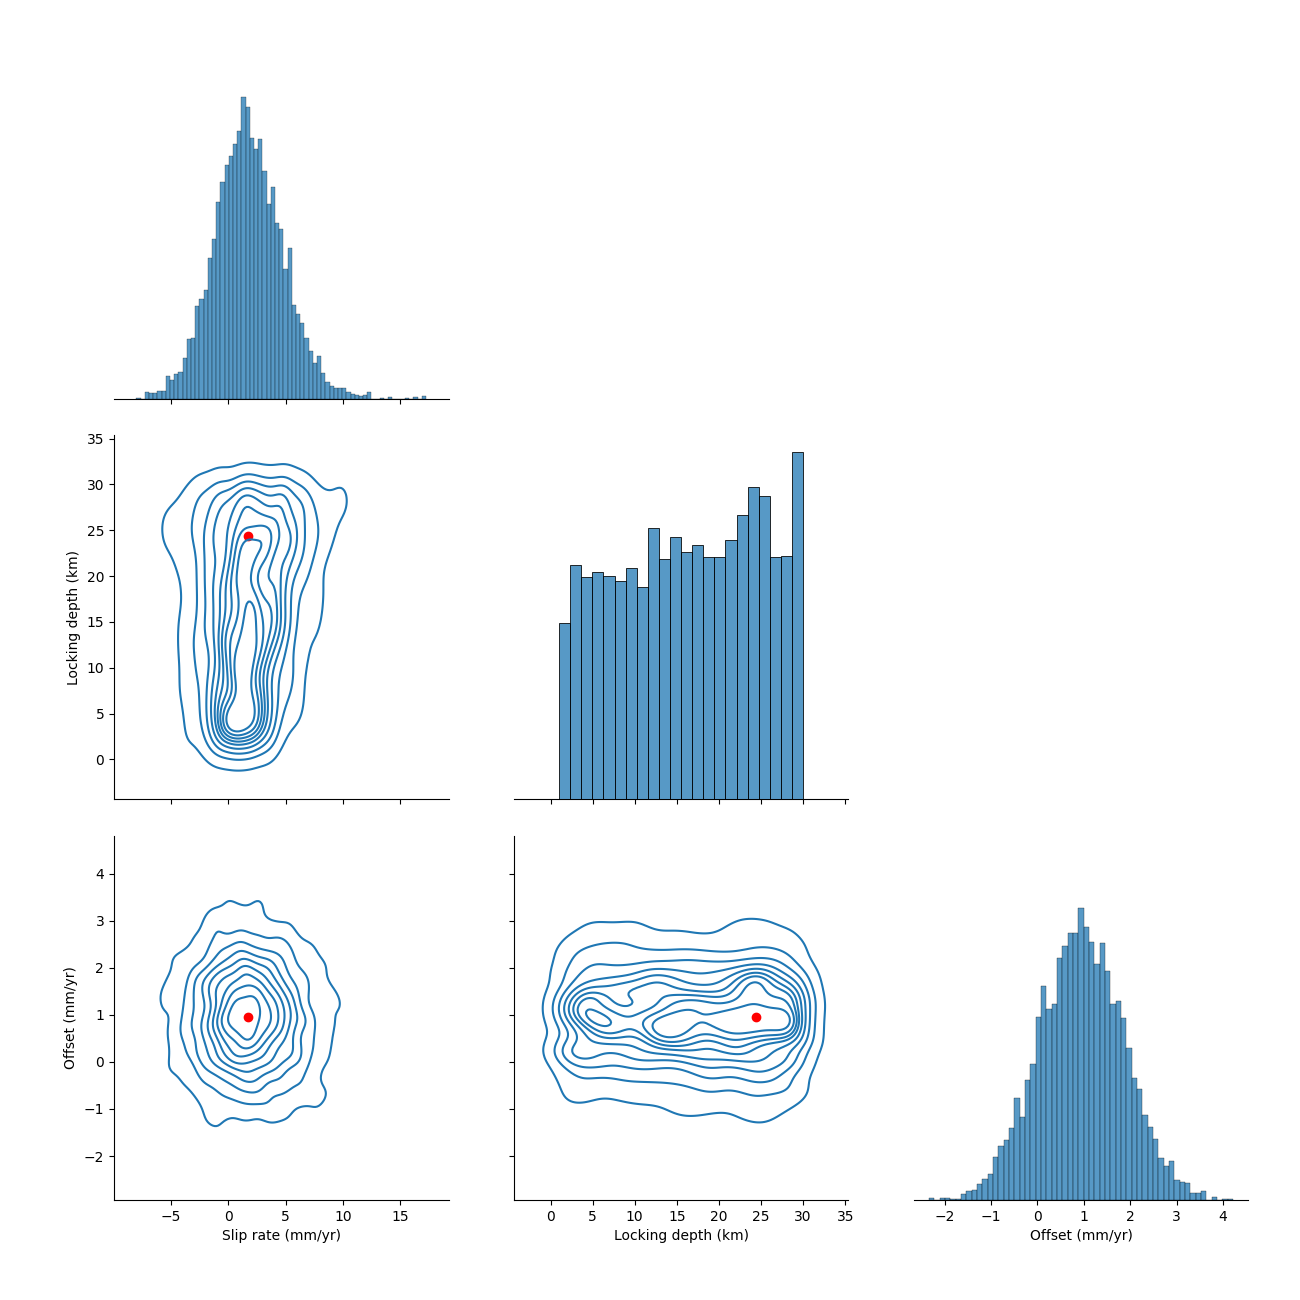

In [89]:
# This plot can take a couple minutes to run (dependent on the number of iterations)

# multivariate plot
models_df = pd.DataFrame(data=models_saved, columns=["Slip rate (mm/yr)", "Locking depth (km)", "Offset (mm/yr)"])
g = sns.PairGrid(models_df, corner=True)
g.map_diag(sns.histplot)
g.map_lower(sns.kdeplot) # use this to plot as contours instead (runs slower)
g.fig.set_size_inches(13,13)

# add red dots for our best model
g.axes[1,0].scatter(best_model[0], best_model[1], c='red')
g.axes[2,0].scatter(best_model[0], best_model[2], c='red')
g.axes[2,1].scatter(best_model[1], best_model[2], c='red')

plt.show()

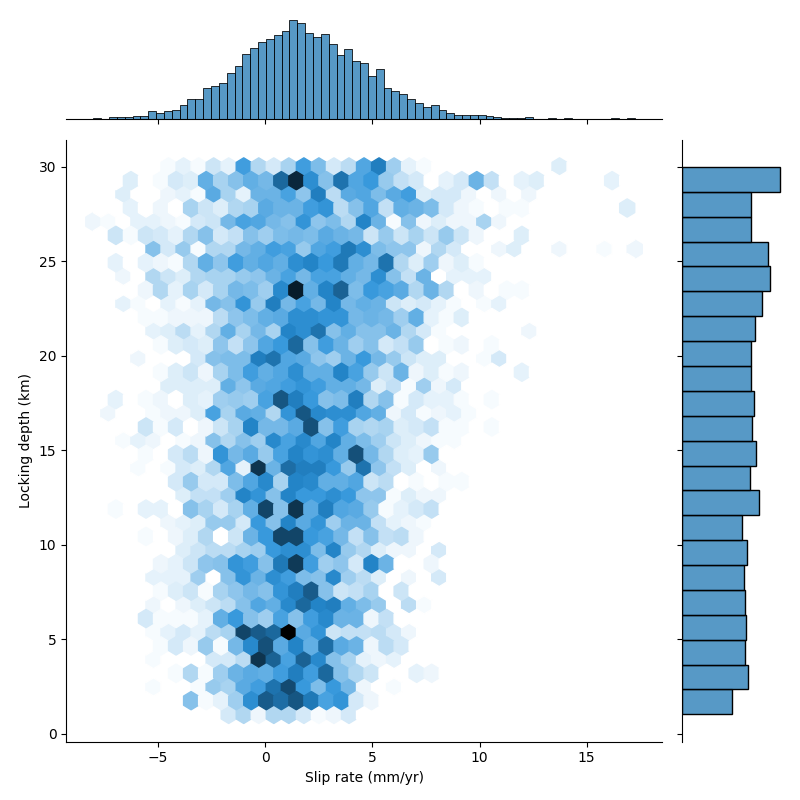

In [90]:
# compare just slip rate and locking depth
models_df = pd.DataFrame(data=models_saved[:,0:2], columns=["Slip rate (mm/yr)", "Locking depth (km)"])
ax = sns.jointplot(data=models_df, x="Slip rate (mm/yr)", y="Locking depth (km)", kind="hex", height=8)
plt.show()

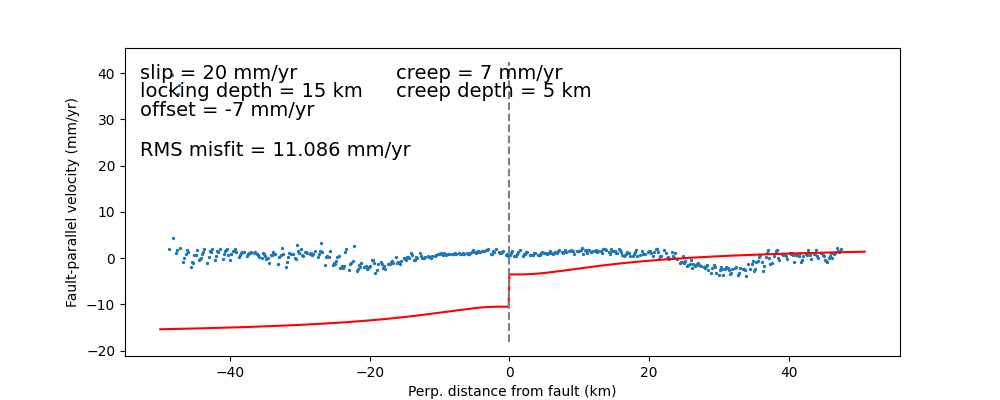

In [66]:
# Slip and locking depth
#####################################
s1 = 20 # mm/yr
s2 = 7 # mm/yr
d1 = 15 # km
d2 = 5 # km
c = -7 # mm/yr
xc = 0 # km
#####################################

# shift profile so thast fault is at 0 km
x_prof = points_dist - intersect_dist

# Vector of positions every 1 km for -100 km to 100 km
x = np.arange(-50,51,0.1)

# run the forward model
v = lib.fault_creep(x*1000, s1/1000, s2/1000, d1*1000, d2*1000, c/1000, xc=xc*1000)

# calculate rms misfit by running the forward model for x positions with velocities
v_forward = lib.fault_creep(x_prof*1000, s1/1000, s2/1000, d1*1000, d2*1000, c/1000, xc=xc*1000)
rms_forward = lib.rms_misfit(points_val,v_forward*1000)

# Plot comparison
fig, axs = plt.subplots(1,1,figsize=(10,4))

plt.scatter(x_prof,points_val,s=2)
plt.plot(x, v*1000, c='r')
plt.plot([0, 0],[axs.get_ylim()[0], axs.get_ylim()[1]], color='grey', linestyle='dashed')

plt.text(0.02, 0.9, 'slip = ' + str(s1) + ' mm/yr', fontsize=14, transform = axs.transAxes)
plt.text(0.35, 0.9, 'creep = ' + str(s2) + ' mm/yr', fontsize=14, transform = axs.transAxes)
plt.text(0.02, 0.84, 'locking depth = ' + str(d1) + ' km', fontsize=14, transform = axs.transAxes)
plt.text(0.35, 0.84, 'creep depth = ' + str(d2) + ' km', fontsize=14, transform = axs.transAxes)
plt.text(0.02, 0.78, 'offset = ' + str(c) + ' mm/yr', fontsize=14, transform = axs.transAxes)
plt.text(0.02, 0.65, 'RMS misfit = ' + str(round(rms_forward,3)) + ' mm/yr', fontsize=14, transform = axs.transAxes)

plt.xlabel('Perp. distance from fault (km)')
plt.ylabel('Fault-parallel velocity (mm/yr)')

plt.show()

In [126]:
# set strike
strike = 83
strike_E, strike_N = np.sin(np.deg2rad(strike)), np.cos(np.deg2rad(strike))

# pre-allocate
vel_para = np.zeros((len(lat_regrid), len(lon_regrid)))
vel_U_new = np.zeros((len(lat_regrid), len(lon_regrid)))


# loop through every pixel
for ii in np.arange(0,len(lat_regrid)):
    for jj in np.arange(0,len(lon_regrid)):
        E = E_regrid[ii, jj]
        N = 0

        # create the design matrix
        G = np.array([[strike_E, strike_N],   # Along the strike
                      [-strike_N, strike_E]]) # Perpendicular to the strike
        
        # Vector of velocities at this pixel (East and North)
        d = np.array([E, N])
        
        # solve the linear system for the Up and East velocities
        m = np.linalg.solve(G, d)
        
        # Solve the linear system Gm = d to find the velocities along and perpendicular to the strike
        m = np.linalg.solve(G, d)

        # save to arrays
        vel_para[ii,jj] = m[0] # vel along strike
        vel_U_new[ii,jj] = m[1] # vel prependicular to strike
        
print('Velocity decomposition complete.')

Velocity decomposition complete.
